In [1]:
import cafe
import scanpy as sc

cafe.settings.backend = "python_function"
cafe.logger.setLevel("DEBUG")
import pandas as pd
import numpy as np
from cafe.data import FateAnnData
from cafe.metric.metric_correlation_v2 import calculate_correlation
from cafe.metric.metric_position_predict_v3 import calculate_position_predict
from cafe.metric.metric_featureimp_v3 import (
    calculate_overall_feature_importance,
    calculate_featureimp_cor,
    calculate_featureimp_enrichment,
    fi_ranger_rf_tiny,
    fi_ranger_rf_lite,
)
from cafe.metric.cluster_metric_v2 import calculate_mapping_branches, calculate_mapping_milestones, calculate_mapping
from cafe.metric._topology_metric.metric_him import calculate_him
from cafe.metric.topology_metric import calc_isomorphic, calculate_edge_flip
import matplotlib.pyplot as plt
import seaborn as sns

[2025年10月09日 15时28分47秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"
cluster_key = "clusters"

fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]
fadata

[2025年10月09日 15时28分48秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
fadata.layers["expression"].toarray()[:20, :20]

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 2., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 2.,
        0., 0., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0.

In [4]:
# Normalization
# Normalizing to median total counts
sc.pp.normalize_total(fadata)
# Logarithmize the data
sc.pp.log1p(fadata)

# Feature selection
sc.pp.highly_variable_genes(fadata, n_top_genes=2000)
fadata = fadata[:, fadata.var.highly_variable]
fadata

[2025年10月09日 15时28分54秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                


AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [5]:
fadata.X.toarray()[:20, :20]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.8110648 , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.8110648 , 2.8480403 , 1.252936  , 0.        ],
       [0.        , 0.        , 1.2886586 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 1.0123078 ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.9249996 , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 2.3156202 , 0.9249996 , 0.        ],
       [0.        , 0.5543057 , 0.90884864, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.5543057 ,
        0.        , 0.        , 0.        , 0

In [6]:
# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


[2025年10月09日 15时29分53秒] DEBUG    plot_trajectory                                                             
[2025年10月09日 15时30分40秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年10月09日 15时30分47秒] DEBUG    add waypoints shape is (212, 3696), finished!                               


AnnData object with n_obs × n_vars = 3696 × 2000
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'log1p', 'hvg', 'milestone_colors', 'milestone_color_colors', 'milestone_color_dict'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

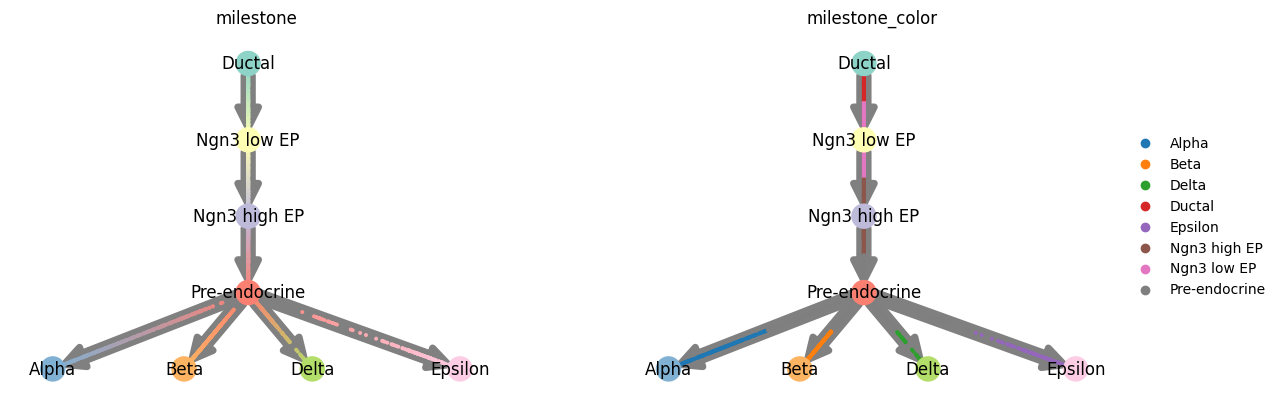

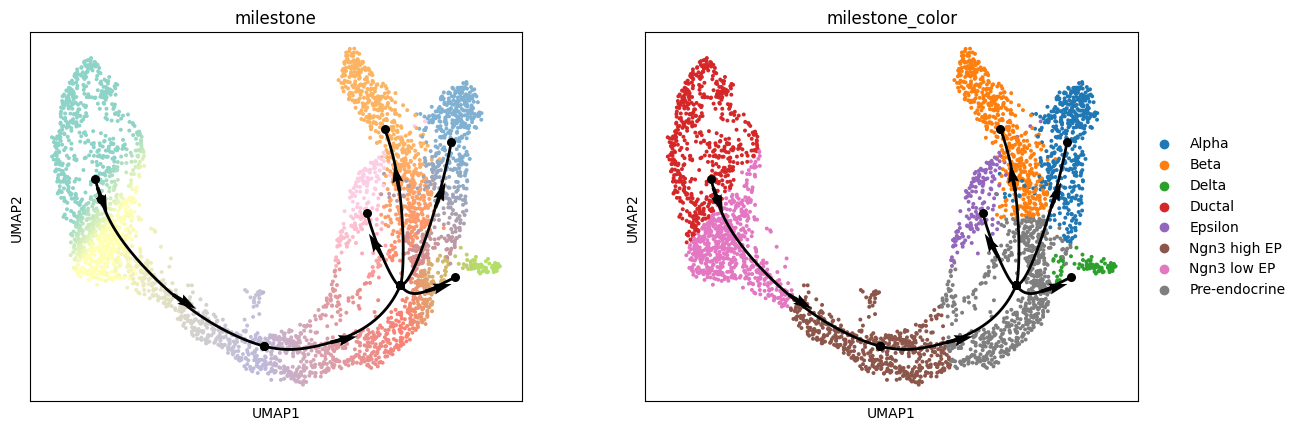

In [7]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key)  # new cluster color
cluster_key_list = ["milestone", cluster_key]
cafe.plot.plot_graph(fadata, color=cluster_key_list)
cafe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

In [8]:
prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

In [9]:
method_name_list = ["comp1", "state_comp", "paga", "cluster_mst", "projection_mst"]
for method_name in method_name_list:
    method = cafe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata)

[2025年10月09日 15时32分07秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x77c72e952560> from                       
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_comp1.py                   
                        INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at       
                                 0x77c77adad600>                                                                   
                        DEBUG    Add trajectory by wrapper type: linear                                            


                        DEBUG    Wrapper type: linear                                                              
                        DEBUG    FateAnnData add_trajectory                                                        
[2025年10月09日 15时32分08秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_state_comp at 0x77c72e7d56c0> from                  
                                 /home/mhn/Code/CellFateExplorer/cfe/method/function/cf_state_comp.py              
                        INFO     method_backend: <cafe.method.fate_function_backend.FunctionBackend object at       
                                 0x77c73edba530>                                                                   
                        DEBUG    Add trajectory by wrapper type: probability                                       
                        DEBUG    Wrapper type: probability                   

In [10]:
parsed_model_name_list = fadata.get_all_model_name()  # 解析后的模型名称
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

                        WARNING  'ref' is not a valid random_time_string, don't need parse                         


(['ref',
  'comp1-python_function',
  'state_comp-python_function',
  'paga-python_function',
  'cluster_mst-python_function',
  'projection_mst-python_function'],
 ['ref',
  '20251009_153207__comp1-python_function__UhjLIalaZA',
  '20251009_153208__state_comp-python_function__wdDYAgo1K9',
  '20251009_153210__paga-python_function__XMLskjdiTr',
  '20251009_153239__cluster_mst-python_function__u4HCQ16vRC',
  '20251009_153242__projection_mst-python_function__6CNCPTcgum'])

In [11]:
new_fadata = cafe.data.FateAnnData(X=fadata.X, obs=fadata.obs, uns=fadata.uns)
for i in model_name_list:
    new_fadata.model_name = i
    new_fadata.milestone_wrapper = fadata.trajectory_history_dict[i]["milestone_wrapper"]
    new_fadata.add_waypoints()
    # 使用单引号避免冲突
    # print(f"{i}'s milestone_network is:\n {new_fadata.milestone_wrapper['milestone_network']}")
    # print(f"{i}'s progressions is:\n {new_fadata.milestone_wrapper['progressions']}")


prior_information = {"start_id": fadata.obs.index[0], "groups_id": fadata.obs[cluster_key].tolist()}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
new_fadata.add_prior_information(**prior_information)  # add prior information to fadata

[2025年10月09日 15时32分44秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月09日 15时32分53秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月09日 15时33分13秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月09日 15时33分38秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月09日 15时33分57秒] DEBUG    FateAnnData add_waypoints                                                   
[2025年10月09日 15时34分06秒] DEBUG    FateAnnData add_waypoints                                                   


In [12]:
new_fadata.prior_information

{'start_id': 'cell_000',
 'groups_id': ['Pre-endocrine',
  'Ngn3 low EP',
  'Alpha',
  'Ductal',
  'Pre-endocrine',
  'Ductal',
  'Alpha',
  'Ductal',
  'Ductal',
  'Ngn3 low EP',
  'Delta',
  'Ductal',
  'Beta',
  'Ductal',
  'Ductal',
  'Ngn3 low EP',
  'Beta',
  'Alpha',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Ngn3 low EP',
  'Epsilon',
  'Beta',
  'Pre-endocrine',
  'Alpha',
  'Alpha',
  'Beta',
  'Beta',
  'Ngn3 low EP',
  'Beta',
  'Ductal',
  'Ngn3 low EP',
  'Alpha',
  'Pre-endocrine',
  'Pre-endocrine',
  'Ductal',
  'Ductal',
  'Beta',
  'Pre-endocrine',
  'Alpha',
  'Beta',
  'Ductal',
  'Alpha',
  'Beta',
  'Beta',
  'Alpha',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Alpha',
  'Epsilon',
  'Alpha',
  'Alpha',
  'Ductal',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Alpha',
  'Ngn3 high EP',
  'Ngn3 high EP',
  'Pre-endocrine',
  'Ductal',
  'Pre-endocrine',
  'Ngn3 high EP',
  'Epsilon',
  'Ngn3 high EP',
  'Beta',
  'Pre-endocrine',
  'Ngn3 high EP',
  'Pre-endoc

开始指标部分的分析

In [13]:
metrics = cafe.metric.metrics
metrics

,metric_id,plotmath,latex,html,long_name,category,type,perfect,worst,symmetric
0,correlation,cor[dist],\mathit{cor}_{\textrm{dist}},cor<sub>dist</sub>,Geodesic distance correlation,cell positions,specific,1,0.0,True
1,rf_mse,MSE[rf],\mathit{MSE}_{\textit{rf}},MSE<sub>rf</sub>,Random Forest MSE,neighbourhood,specific,0,0.3,False
2,rf_nmse,NMSE[rf],\mathit{NMSE}_{\textit{rf}},NMSE<sub>rf</sub>,Random Forest Normalised MSE,neighbourhood,specific,1,0.0,False
3,rf_rsq,R[rf]^2,R^{2}_{rf},R<sup>2</sup><sub>rf</sub>,Random Forest R²,neighbourhood,specific,1,0.0,False
4,lm_nmse,NMSE[lm],\mathit{NMSE}_{\textit{lm}},NMSE<sub>lm</sub>,Linear regression Normalised MSE,neighbourhood,specific,1,0.0,False
5,lm_mse,MSE[lm],\mathit{MSE}_{\textit{lm}},MSE<sub>lm</sub>,Linear regression MSE,neighbourhood,specific,0,0.3,False
6,lm_rsq,R[lm]^2,R^{2}_{lm},R<sup>2</sup><sub>lm</sub>,Linear regression R²,neighbourhood,specific,1,0.0,False
7,edge_flip,edgeflip,\textrm{edgeflip},edgeflip,Edge flip,topology,specific,1,0.0,True
8,him,HIM,\textrm{HIM},HIM,Hamming-Ipsen-Mikhailov similarity,topology,specific,1,0.0,True
9,isomorphic,isomorphic,\textrm{isomorphic},Isomorphic,isomorphic,topology,specific,1,0.0,True


拓扑部分

In [14]:
# metric_topology_dict = {}
# metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
# for model_name in model_name_list:
#     model_metric = cafe.metric.calculate_metrics(
#         fadata,
#         metrics=metric_id_list,
#         now_model=model_name,
#         ref_model="ref"
#     )
#     metric_topology_dict[model_name] = model_metric

# df = pd.DataFrame(metric_topology_dict).T
# df.index=parsed_model_name_list
# df

In [15]:
# #可视化指标
# plt.figure(figsize=(10, 6))
# # 创建热力图
# ax = sns.heatmap(
#     df,
#     annot=True,          # 显示数值
#     fmt=".2f",          # 数值格式（保留2位小数）
#     cmap="viridis",      # 颜色方案
#     linewidths=0.5,     # 单元格边线宽度
#     linecolor="white",  # 单元格边线颜色
#     vmin=0,             # 颜色范围最小值
#     vmax=1              # 颜色范围最大值
# )

# # 调整坐标标签
# plt.xticks(rotation=45, ha="right")  # 旋转列标签
# plt.yticks(rotation=0)               # 保持行标签水平
# plt.xlabel("Metrics")                # x轴标签
# plt.ylabel("Models")                 # y轴标签
# plt.title("Model Performance Metrics Heatmap")  # 标题

# # 显示图形
# plt.tight_layout()
# plt.show()

查看correlation表现

In [16]:
# metric_correlation_dict = {}
# metric_id_list = metrics[metrics["category"] == "cell positions"]["metric_id"].tolist()
# for model_name in model_name_list:
#     model_metric = cafe.metric.calculate_metrics(
#         fadata,
#         metrics=metric_id_list,
#         now_model=model_name,
#         ref_model="ref"
#     )
#     metric_correlation_dict[model_name] = model_metric

# df = pd.DataFrame(metric_correlation_dict).T
# df.index=parsed_model_name_list
# df

查看各个F1 score的表现

In [17]:
# #映射到里程碑上
# F1_dict={}
# for i,j in zip(model_name_list,parsed_model_name_list):
#     F1_dict[j]=calculate_mapping(new_fadata,grouping='branches',simplify=True,ref_model= "ref",pred_model= i)

# df = pd.DataFrame.from_dict(F1_dict, orient='index')
# df

In [18]:
# #可视化指标
# plt.figure(figsize=(10, 6))
# # 创建热力图
# ax = sns.heatmap(
#     df,
#     annot=True,          # 显示数值
#     fmt=".2f",          # 数值格式（保留2位小数）
#     cmap="viridis",      # 颜色方案
#     linewidths=0.5,     # 单元格边线宽度
#     linecolor="white",  # 单元格边线颜色
#     vmin=0,             # 颜色范围最小值
#     vmax=1              # 颜色范围最大值
# )

# # 调整坐标标签
# plt.xticks(rotation=45, ha="right")  # 旋转列标签
# plt.yticks(rotation=0)               # 保持行标签水平
# plt.xlabel("Metrics")                # x轴标签
# plt.ylabel("Models")                 # y轴标签
# plt.title("Model Performance Metrics Heatmap")  # 标题

# # 显示图形
# plt.tight_layout()
# plt.show()

试试position_predict相关指标的表现

In [19]:
parsed_model_name_list

['ref',
 'comp1-python_function',
 'state_comp-python_function',
 'paga-python_function',
 'cluster_mst-python_function',
 'projection_mst-python_function']

In [20]:
# position_predict_dict={}
# for i,j in zip(model_name_list,parsed_model_name_list):
#     position_predict_dict[j]=calculate_position_predict(
#         new_fadata,
#         ref_model='ref',
#         pred_model=i,
#         metrics=["rf_mse","rf_rsq","rf_nmse","lm_mse","lm_rsq","lm_nmse"]
#     )['summary']

# position_predict_dict

In [21]:
# df = pd.DataFrame.from_dict(position_predict_dict, orient='index')
# df

In [22]:
# print(df)

计算cor和wcor相关的表现(这里利用fadata，因为new_fadata在表达矩阵上可能存在问题)

In [23]:
featureimp_dict = {}
for i, j in zip(model_name_list, parsed_model_name_list):
    featureimp_dict[j] = calculate_featureimp_cor(fadata, "ref", i, "expression", fi_ranger_rf_tiny())

featureimp_dict

{'ref': {'featureimp_cor': 1.0, 'featureimp_wcor': 1.0},
 'comp1-python_function': {'featureimp_cor': 0.5523845237341356,
  'featureimp_wcor': 0.523855818962871},
 'state_comp-python_function': {'featureimp_cor': 0.6611783859414362,
  'featureimp_wcor': 0.5970529874259903},
 'paga-python_function': {'featureimp_cor': 0.8628058752878472,
  'featureimp_wcor': 0.762802901970613},
 'cluster_mst-python_function': {'featureimp_cor': 0.9485421844655194,
  'featureimp_wcor': 0.9240811546491552},
 'projection_mst-python_function': {'featureimp_cor': 0.9264769712379547,
  'featureimp_wcor': 0.9066254507176141}}

In [24]:
df = pd.DataFrame.from_dict(featureimp_dict, orient="index")
df

,featureimp_cor,featureimp_wcor
ref,1.000000,1.000000
comp1-python_function,0.552385,0.523856
state_comp-python_function,0.661178,0.597053
paga-python_function,0.862806,0.762803
cluster_mst-python_function,0.948542,0.924081
projection_mst-python_function,0.926477,0.906625
